In [24]:
import torch
from transformers import AutoModelForSequenceClassification
from transformers import BertTokenizerFast
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
tokenizer = BertTokenizerFast.from_pretrained('blanchefort/rubert-base-cased-sentiment')
model = AutoModelForSequenceClassification.from_pretrained('blanchefort/rubert-base-cased-sentiment', return_dict=True)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: blanchefort/rubert-base-cased-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
# определение тональности
def analyze_sentiment(text):
    inputs = tokenizer(text, max_length=512, padding=True, truncation=True, return_tensors='pt')
    outputs = model(**inputs)
    predicted = torch.nn.functional.softmax(outputs.logits, dim=1)
    predicted = torch.argmax(predicted, dim=1).item()
    return predicted

df = pd.read_csv('cafe_reviews.csv', encoding='utf-8')
df['predicted_sentiment'] = df['text'].apply(analyze_sentiment)

# изменение формата представления тональности
df['predicted_sentiment'] = df['predicted_sentiment'].map({0: 'Neutral', 1: 'Positive', 2: 'Negative'})

                                                text predicted_sentiment
0  Самая любимая кафешка на районе: вкуснейший ко...            Positive
1  Ну , вот добрался наконец и до вас 👌 Что можно...            Negative
2  Шикарное место, вкусно готовит, приятная атмос...            Positive
3  23.02.23 отмечали день рождение в Роще, столик...             Neutral
4  Отличная база отдыха, часто с семьей отдыхаем ...            Positive


In [27]:
# счет отзывов в каждой категории тональности - высота столбцов на графике
counts = df['predicted_sentiment'].value_counts()

predicted_sentiment
Positive    50
Negative    41
Neutral      9
Name: count, dtype: int64


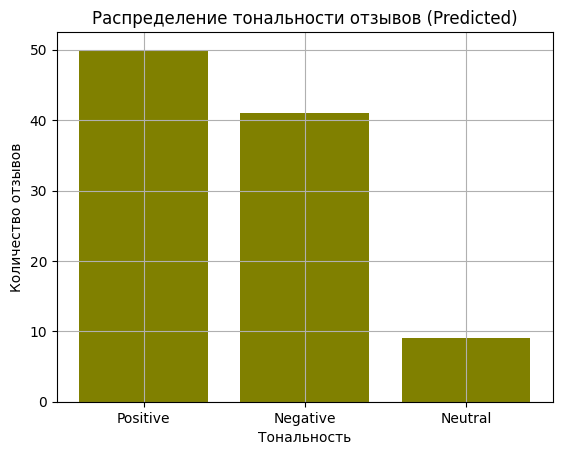

In [30]:
# создание столбчатой диаграммы, отражающей количество отзывов для каждой тональности
plt.bar(counts.index, counts.values, color='olive')
plt.title('Распределение тональности отзывов (Predicted)')
plt.xlabel('Тональность')
plt.ylabel('Количество отзывов')
plt.grid(True)
plt.show()